---
# SFPPy Example: mass transfer from chained steps and complex scenarios
---

## Example 3: Advanced Migration Simulation with Variants
------------------------------------------------------

### Scenario: Mass Transfer in a Multilayer Packaging System
--------------------------------------------------------
This example simulates the migration of **limonene** from a recycled **polypropylene (PP)** core
to food, using a **trilayer packaging (ABA structure)** where **A = PET** and **B = PP**.
The study follows three consecutive storage and processing steps:

1. Storage at ambient temperature (20°C) for 4 months
2. Hot-filling at 90°C with a fatty food
3. Storage at 30°C for 6 months

Limonene is initially present in **B at 200 mg/kg**. The layer thicknesses are:
- PET (A): **20 µm**
- PP (B): **500 µm**

Variants Studied:
- **Variant 1**: Replace limonene with toluene
- **Variant 2**: Reduce B’s thickness from 20 µm to 10 µm for both limonene and toluene
- **Variant 3**: Combination of Variant 1 and Variant 2

All four conditions (Reference, Variant 1, Variant 2, and Variant 3) are compared in a single
figure, with results exported to **Excel and CSV** for further analysis.

--------------------------------------------------------
### Exploring SFPPy’s Database
--------------------------------------------------------
This example allows interaction with **SFPPy’s extensive databases**, including:
- **3D geometries** (predefined packaging shapes)
- **Chemical substances** (millions via PubChem)
- **Food contact conditions** (various storage and processing scenarios)
- **Polymers and materials** (tens of predefined types)

--------------------------------------------------------
### Key Features and Pythonic Syntax
--------------------------------------------------------

1. **Compact and Concise Code Structure**
Example 3 demonstrates **chained simulations** with **minimal coding**, contrasting with
Examples 1 and 2. The approach **stores results within objects**, enabling streamlined operations.

2. **Operator `>>` for Seamless Processing**
The `>>` operator automates **property propagation** and **mass transfer simulations**:
- `mypackaging >> myfood` → Updates **food geometry**
- `food1 >> food2` → Synchronizes food properties
- `myfood >> mymaterial` → Transfers **temperature**
- `mymaterial >> myfood` → Simulates **mass transfer**

Example: `mypackaging >> myfood >> mymaterial >> myfood` performs:
1. **Update food geometry** to match packaging
2. **Transfer temperature** to the material
3. **Simulate mass transfer** from material to food

For multiple contact conditions:
`mypackaging >> foodcontact2 >> foodcontact1 >> mymaterial >> foodcontact1 >> foodcontact2`
- Adjusts food geometry (`foodcontact1`, `foodcontact2`)
- Transfers **temperature** (`foodcontact1 >> mymaterial`)
- Simulates mass transfer and propagates results
- Final results stored in **foodcontact1.lastsimulation, foodcontact2.lastsimulation**

To explicitly save results: `result = ... step n >> step n+1`
Dynamic updates:
`foodcontact1 >> mymaterial.update(substance="new migrant", l=new_thickness) >> foodcontact1`

3. **Operator `+` for Combining Results**
- **Material assembly:** `ABA = A + B + A` (trilayer structure)
- **Merging simulation results:** `fullsolution = foodcontact1.lastsimulation + foodcontact2.lastsimulation`

4. **Comprehensive Result Output**
- **Visualization:** Results can be plotted directly
- **Exporting:** Save to **Excel** (`.xlsx`) and **CSV** (`.csv`)

--------------------------------------------------------
### Summary
--------------------------------------------------------
Example 3 demonstrates **efficient chaining of migration simulations** using intuitive operators
(`>>` for sequential processing, `+` for merging results). SFPPy’s powerful database and
Pythonic syntax enable complex simulations with minimal effort.


@project: SFPPy - SafeFoodPackaging Portal in Python initiative
@author: INRAE\\olivier.vitrac@agroparistech.fr
@licence: MIT

In [4]:
# -----------------
# Define the output directory to store results.
import os
outputfolder = os.path.join(os.getcwd(), "tmp")  # Full path
os.makedirs(outputfolder, exist_ok=True)  # Create folder if missing

In [6]:
# ---------------------
"""
Identify and select a suitable 3D packaging geometry.
The function `help_geometry()` lists available shapes.

Example: `box_container` is a rectangular prism with one open face.
Its volume and surface area are computed as:
    Volume = length × width × height
    Surface Area = 2(lw + lh + wh) - lw  (removing the open top)
"""
# Import the geometry module
from patankar.geometry import Packaging3D, help_geometry

# Display available geometries and required parameters
help_geometry()

# Define the container as an open rectangular prism
container = Packaging3D('box_container', height=(8, "cm"), width=(10, "cm"), length=(19, "cm"))

=== List of Implemented Geometries & Synonyms ===

Shape Class: Cone
  Synonyms       : cone
  Required Params: radius, height
    A full cone with closed circular base.
    Volume = (1/3) π r² h. Surface area = base + lateral area.
------------------------------------------------------------
Shape Class: Cylinder
  Synonyms       : can, cylinder
  Required Params: radius, height
    A standard cylinder with top and bottom faces.
    Volume = π r² h. Surface area includes top and bottom disks.
------------------------------------------------------------
Shape Class: Hemisphere
  Synonyms       : bowl, hemisphere
  Required Params: radius
    A hemisphere (half a sphere) typically open at the flat side.
    Volume = (2/3) π r³. Surface area = 3π r² (2πr² curved + πr² open).
------------------------------------------------------------
Shape Class: OpenCone
  Synonyms       : open_cone
  Required Params: radius, height
    A cone with its base removed, leaving a single open circular face.

In [8]:
# ---------------------
# Retrieve the properties of the migrating substance.
from patankar.loadpubchem import migrant

# Search for limonene in PubChem and retrieve chemical properties.
m = migrant("limonene")

In [10]:
# -------------------------
"""
List available polymer/material options for packaging.
Use `help_layer()` to display predefined materials.

| Class Name | Type     | Material                 | Code |
|------------|---------|---------------------------|------|
| PP         | polymer | Isotactic Polypropylene   | PP   |
| gPET       | polymer | Glassy PET                | PET  |
"""
# Import material properties
from patankar.layer import help_layer, layer

# Display available polymer options
help_layer()

# Import required polymer classes (Polypropylene, PET)
from patankar.layer import gPET, PP

| Class Name              | Type     | Material                        | Code    |
|-------------------------|----------|---------------------------------|---------|
| AdhesiveAcrylate        | adhesive | acrylate adhesive               | Acryl   |
| AdhesiveEVA             | adhesive | EVA adhesive                    | EVA     |
| AdhesiveNaturalRubber   | adhesive | natural rubber adhesive         | rubber  |
| AdhesivePU              | adhesive | polyurethane adhesive           | PU      |
| AdhesivePVAC            | adhesive | PVAc adhesive                   | PVAc    |
| AdhesiveSyntheticRubber | adhesive | synthetic rubber adhesive       | sRubber |
| AdhesiveVAE             | adhesive | VAE adhesive                    | VAE     |
| Cardboard               | paper    | cardboard                       | board   |
| HDPE                    | polymer  | high-density polyethylene       | HDPE    |
| HIPS                    | polymer  | high-impact polystyrene         | HIPS    |
| LD

In [12]:
# ----------------------
"""
Define and configure the layers for the multilayer packaging.
Each layer has properties such as:
    - Thickness (`l`)
    - Initial concentration (`C0`)
    - Migrant type (`substance`, `migrant`, etc.)

Property synonyms:
| Parameter  | Synonyms                  |
|------------|---------------------------|
| substance  | molecule, solute, migrant |
| C0         | Cp0, CP0                  |
| l          | lp, lP                    |
"""
# Define the PET (A) and PP (B) layers
A = gPET(l=(20, "um"), migrant=m, C0=0)       # 20 µm PET with no initial migrant
B = PP(l=(0.5, "mm"), migrant=m, CP0=200)    # 500 µm PP with 200 mg/kg limonene

# Assemble the multilayer structure: ABA configuration
ABA = A + B + A

# Display basic information (default temperature: 40°C)
print("\nOur ABA technology\n", repr(ABA))


[LAYER object version=1, contact=olivier.vitrac@agroparistech.fr]
3-multilayer of LAYER object:
-- [ layer 1 of 3 ] ---------- barrier rank=2 --------------
      name: "layer in gPET"
      type: "polymer"
  material: "glassy PET"
      code: "PET"
         l: 2e-05 [meter]
         D: 1.933e-17 [m**2/s]
          = Dpiringer(gPET,<migrant: Kautschin - M=136.23 g/mol>,T=40.0 degC)
         k: 0.5494 [a.u.]
          = kFHP(<ethylene terephthalate>,<migrant: Kautschin - M=136.23 g/mol>)
        C0: 0 [a.u.]
         T: 40 [degC]
-- [ layer 2 of 3 ] ---------- barrier rank=3 --------------
      name: "layer in PP"
      type: "polymer"
  material: "isotactic polypropylene"
      code: "PP"
         l: 0.0005 [meter]
         D: 4.258e-13 [m**2/s]
          = Dpiringer(PP,<migrant: Kautschin - M=136.23 g/mol>,T=40.0 degC)
         k: 2.161 [a.u.]
          = kFHP(<propylene>,<migrant: Kautschin - M=136.23 g/mol>)
        C0: 200 [a.u.]
         T: 40 [degC]
-- [ layer 3 of 3 ] --------

In [14]:
# -----------------------------------------
"""
Define different storage and processing conditions.
Use `help_food()` to display available predefined food-contact scenarios.

| Class Name  | Description              | Level  | Inheritance    | Parameters        |
|-------------|--------------------------|--------|----------------|-------------------|
| fat        | Fat contact               | root   |chemicalaffinity| k0                |
| liquid     | Liquid food               | root   | texture        | h                 |
| ambient    | Ambient storage           | contact| realcontact    | contacttemperature|
| hotfilled  | Hot-filling               | contact| realcontact    | contacttemperature|
| stacked    | Stacked storage           | user   | setoff         | h                 |
"""
from patankar.food import help_food
help_food()

# Import relevant food-contact conditions
from patankar.food import realfood, liquid, fat, ambient, hotfilled, stacked

# Define three food-contact conditions
class contact1(stacked, ambient):
    name = "1:setoff"
    contacttemperature = (20, "degC")
    contacttime = (3, "months")

class contact2(hotfilled, realfood, liquid, fat):
    name = "2:hotfilling"

class contact3(ambient, realfood, liquid, fat):
    name = "3:storage"
    contacttime = (6, "months")

# Instantiate food-contact conditions
medium1 = contact1(contacttime=(4, "months"))  # Adjust time
medium2 = contact2()
medium3 = contact3()

| Class Name       | Name                 | Description          | Level    | Inheritance          | Init Params          |
|------------------|----------------------|----------------------|----------|----------------------|----------------------|
| foodphysics      | food physics         | Root physics class   | base     | object               |                      |
|                  |                      | used to implement    |          |                      |                      |
|                  |                      | food and mass        |          |                      |                      |
|                  |                      | transfer physics     |          |                      |                      |
| aqueous          | aqueous contact      | minimize mass        | root     | chemicalaffinity     | k                    |
|                  |                      | transfer             |          |                      |                      |
| chemic

In [15]:
# --------------------------------------------
"""
Use the `>>` operator to propagate the packaging properties (volume, surface area)
to all food-contact conditions.

Example:
    container >> medium1 >> medium2 >> medium3
"""
container >> medium1 >> medium2 >> medium3

Food object "3:storage" (ambient storage conditions) with properties:
               CF0: 0 [a.u.]
contacttemperature: 25 [degC]
       contacttime: 15778800 [second]
           density: 1000 [kilogram / meter ** 3]
                 h: 1e-06 [meter / second]
       surfacearea: 0.0654 [meter ** 2]
            volume: 0.001 [meter ** 3]


<contact3: 3:storage>

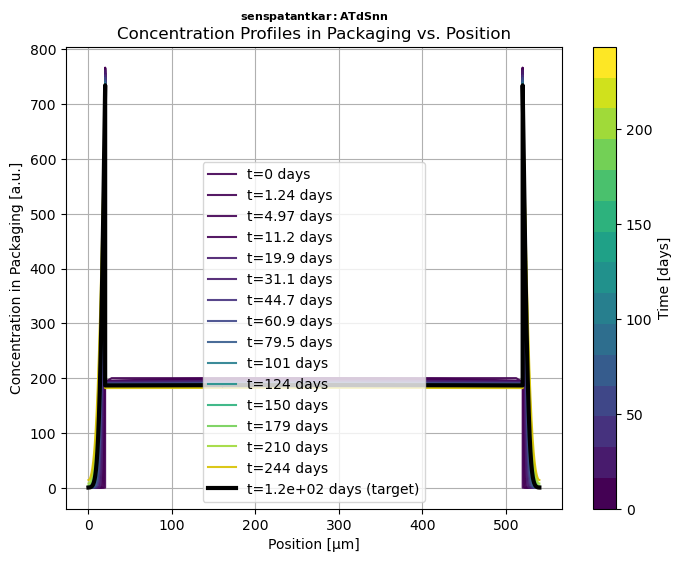

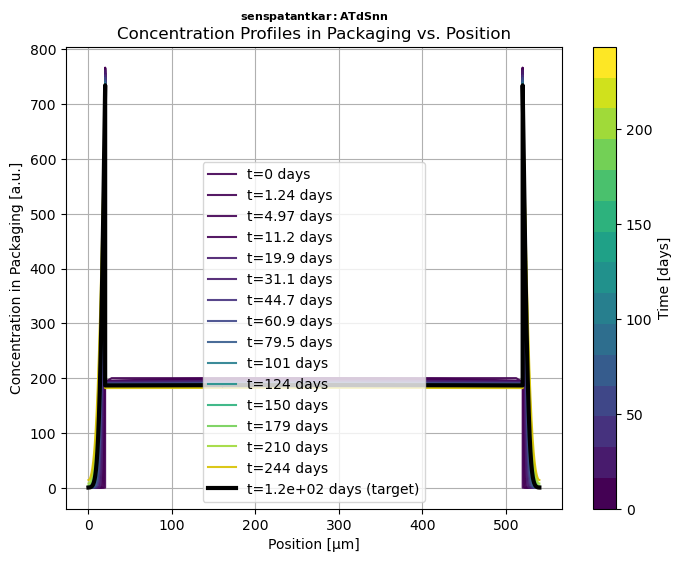

In [18]:
# ------------------
"""
Chain operations using `>>`:
1. Transfer temperature from `medium1` to `ABA`
2. Simulate mass transfer from `ABA` to `medium1`
"""
medium1 >> ABA
medium1 >> ABA >> medium1

# Verify simulation results
medium1.lastsimulation.plotCx()

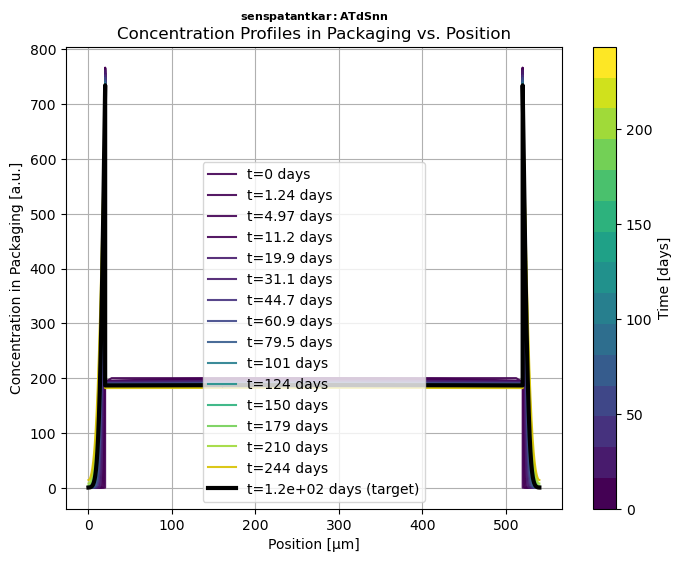

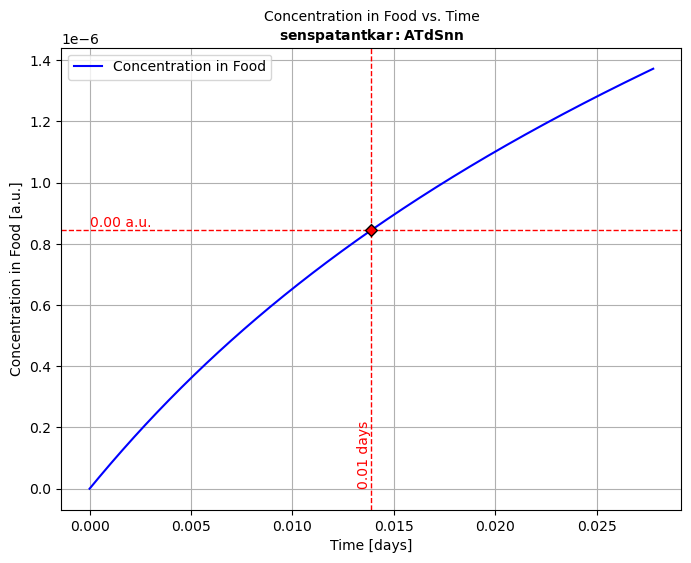

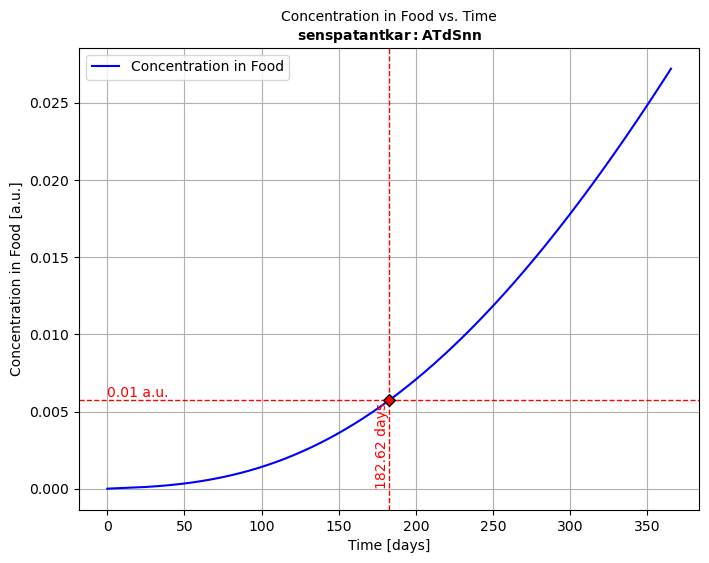

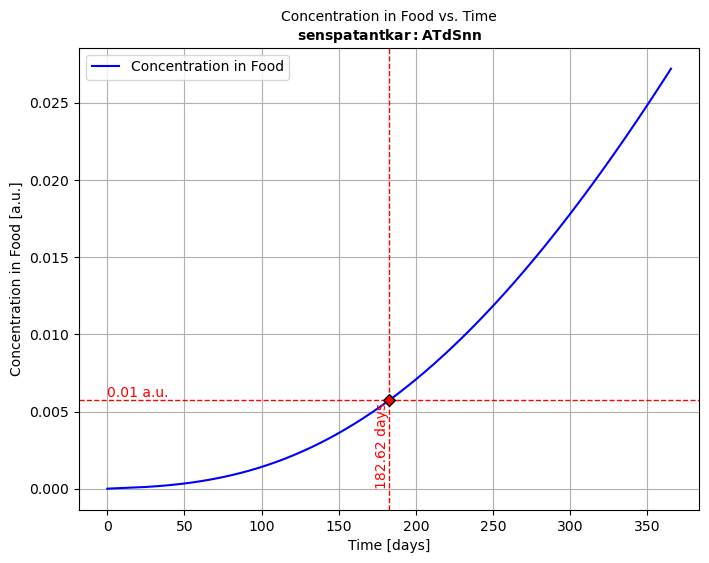

In [19]:
# -----------------------------------------------
"""
Continue simulation by chaining:
    medium1 >> ABA >> medium1 >> medium2 >> medium3

All results are stored inside:
    medium1.lastsimulation, medium2.lastsimulation, medium3.lastsimulation
"""
medium1 >> ABA >> medium1 >> medium2 >> medium3

# Plot migration kinetics
medium1.lastsimulation.plotCx()
medium2.lastsimulation.plotCF()
medium3.lastsimulation.plotCF()

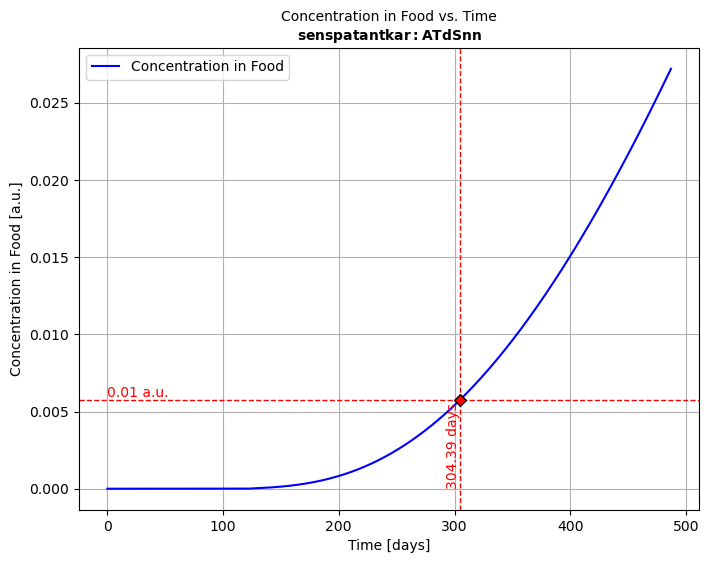

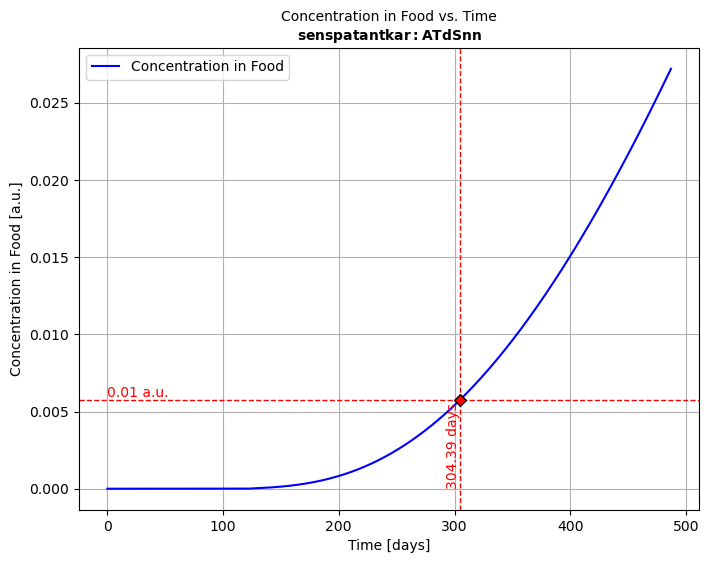

In [20]:
# ---------------------------------------------------
"""
Use `+` operator to merge kinetic profiles.
"""
sol123 = medium1.lastsimulation + medium2.lastsimulation + medium3.lastsimulation
sol123.plotCF()

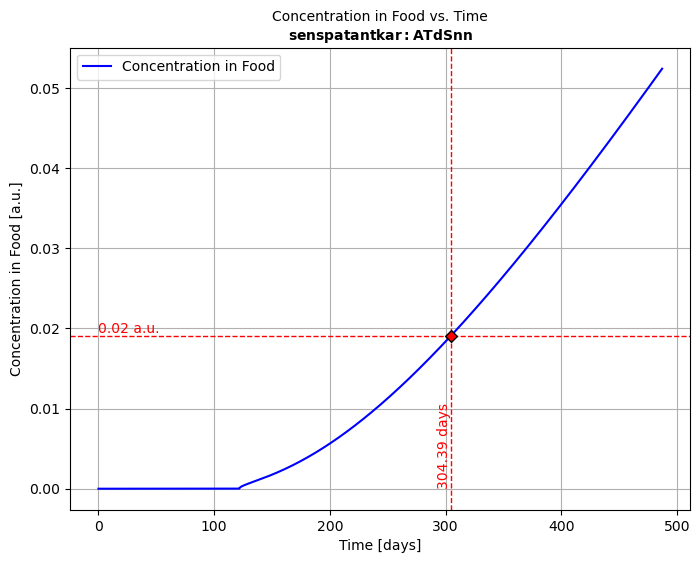

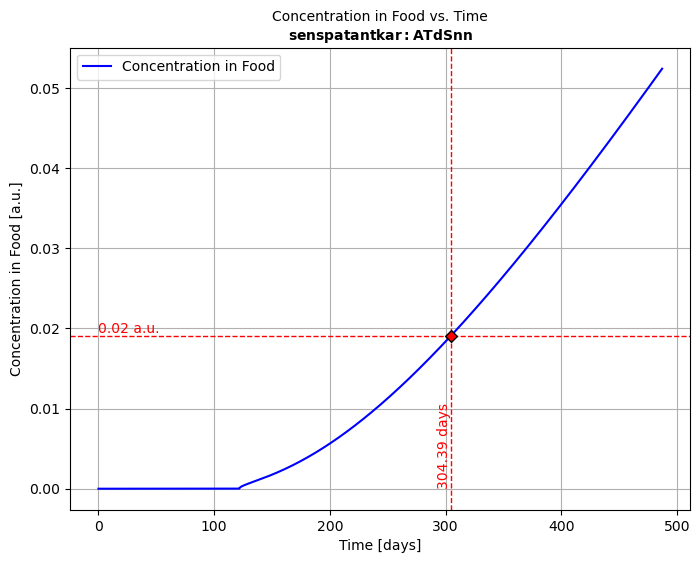

In [21]:
# -------------------------------------------
"""
Repeat all steps using toluene instead of limonene.
"""
m2 = migrant("toluene")  # Retrieve new migrant

# Restart the simulation pipeline with updated migrant
medium1 @ ABA.update(solute=m2) >> medium1 >> medium2 >> medium3

# Store results
sol123_variant1 = medium1.lastsimulation + medium2.lastsimulation + medium3.lastsimulation
sol123_variant1.plotCF()

In [22]:
# --------------------------------------------------
"""
Halve the thickness of the first and last layers (A) while keeping PP constant.
"""
refthickness = ABA.l.copy()
newthickness = refthickness
newthickness[[0, -1]] /= 2  # Reduce thickness of A layers (index 0=first layer in contact with food, index -1= last layer)

# Restart simulation with modified structure
medium1 >> ABA.copy(l=newthickness, migrant=m) >> medium1 >> medium2 >> medium3
sol123_variant2 = medium1.lastsimulation + medium2.lastsimulation + medium3.lastsimulation

In [23]:
# ---------------------------------------------
"""
Use both modifications:
- Toluene as the migrant
- Reduced PET layer thickness

Here @ replaces the first >>, they are equivalent
"""
medium1 @ ABA.copy(l=newthickness, migrant=m2) >> medium1 >> medium2 >> medium3
sol123_variant3 = medium1.lastsimulation + medium2.lastsimulation + medium3.lastsimulation

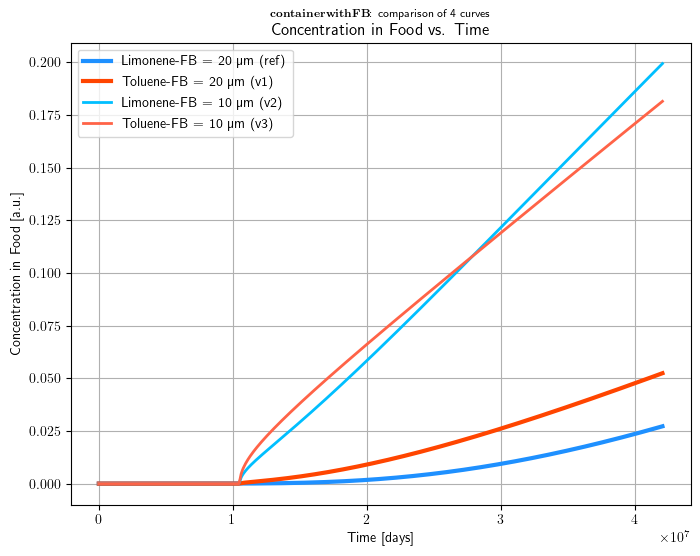

In [25]:
# ---------------------------------
"""
Store and compare all solutions using `CFSimulationContainer`.
"""
from patankar.migration import CFSimulationContainer as store

# Initialize collection
collection = store(name="container with FB")

# Add results to collection
collection.add(sol123, "Limonene-FB = 20 µm (ref)", "dodgerblue", linewidth=3)
collection.add(sol123_variant1, "Toluene-FB = 20 µm (v1)", "orangered", linewidth=3)
collection.add(sol123_variant2, "Limonene-FB = 10 µm (v2)", "deepskyblue", linewidth=2)
collection.add(sol123_variant3, "Toluene-FB = 10 µm (v3)", "tomato", linewidth=2)

# Plot comparative migration kinetics
collection_fig = collection.plotCF()

In [26]:
# ----------------------------------------
"""
Save simulation results for further analysis.
"""
printconfig = {"destinationfolder": outputfolder, "overwrite": True}
collection_fig.print(**printconfig)

# Export data
collection.save_as_csv(filename="example3.csv", destinationfolder=outputfolder, overwrite=True)

# saving to Excel requires: openpyxl >= 3.0.10
# (install it with `conda install openpyl` if you encounter an error message)
collection.save_as_excel(filename="example3.xlsx", destinationfolder=outputfolder, overwrite=True)

no valid figure
Saved CSV file: /home/olivi/natacha/python/tmp/example3.csv
Saved Excel file: /home/olivi/natacha/python/tmp/example3.xlsx
